# 4. Metric Selection

In this notebook, we determine the best evaluation metric for our chess position evaluator. We need to answer a fundamental question:

**Do we need exact centipawn values, or just correct position ordering?**

The answer depends on how our model will be used. Since we're building an evaluator for a **min-max decision system** (chess engine), we care primarily about **comparing positions** to choose the best move, not predicting exact centipawn values.

We will:
1. Explain why traditional regression metrics (RMSE, $R^2$) may not be optimal
2. Introduce alternative metrics: Spearman rank correlation, sign accuracy, tolerance accuracy
3. Compare metrics on a simple model
4. Justify our final choice: **Spearman rank correlation**

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

from chess_eval.managers import DataManager, ModelManager, MetricsManager
from chess_eval.features import FEATURE_TRANSFORMERS
from chess_eval.config import *

# Disable LaTeX rendering
plt.rcParams['text.usetex'] = False
sns.set_style("whitegrid")

## Alternative Metrics for Chess

Let's introduce metrics that better reflect what matters for chess engines:

### 1. Spearman Rank Correlation

Measures how well the model preserves the **ranking** of positions:

$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

where $d_i$ is the difference between ranks of prediction and true value.

- **Range**: [-1, 1] where 1 = perfect ranking, 0 = no correlation, -1 = opposite ranking
- **Property**: Invariant to monotonic transformations (e.g., multiplying all predictions by 2)
- **Focus**: Correct ordering, not exact values

### 2. Sign Accuracy

Fraction of positions where we predict the correct winner:

$$\text{Sign Accuracy} = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}[\text{sign}(y_i) = \text{sign}(\hat{y}_i)]$$

- **Range**: [0, 1] where 1 = always predict correct winner
- **Property**: Only cares about winning/losing/drawing
- **Limitation**: Doesn't distinguish between +50 and +500 (both are "white winning")

### 3. Tolerance Accuracy

Fraction of predictions within ±tolerance centipawns:

$$\text{Tolerance Accuracy}(t) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}[|y_i - \hat{y}_i| \leq t]$$

- **Range**: [0, 1] for a given tolerance $t$
- **Property**: Relaxed version of exact accuracy
- **Use case**: When approximate values are acceptable (e.g., ±200 centipawns)

## Load Data and Train Simple Model

Let's train a simple Ridge regression model with all features to compare metrics.

In [3]:
dm = DataManager(
    read_size=500_000,
    sample_size=100_000,
    transformers=FEATURE_TRANSFORMERS,
    random_state=42
)

print(f"Dataset shape: {dm.df.shape}")
print(f"Features: {len(dm.X_train.columns)}")
print(f"Train size: {len(dm.X_train)}, Test size: {len(dm.X_test)}")

Dataset shape: (100000, 83)
Features: 81
Train size: 80000, Test size: 20000


In [4]:
model = Ridge(alpha=1.0, random_state=42)
mm = ModelManager(model)
mm.fit(dm.X_train, dm.y_train)
mm.predict(dm.X_test)

array([ -22.72989185,   30.14617559,  186.96376883, ...,   56.5248379 ,
       -101.23883419,  -39.12852828], shape=(20000,))

## Compare All Metrics

Let's compute and compare all available metrics.

In [5]:
metrics_m = MetricsManager(mm, dm)
metrics = metrics_m.compute_metrics(tol=200)
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
metrics_df = metrics_df.round(4)

print("\nModel Performance Metrics:\n")
print(metrics_df.to_string(index=False))


Model Performance Metrics:

         Metric    Value
  Spearman Rank   0.5452
Accuracy (±200)   0.7727
           RMSE 215.8642
Accuracy (sign)   0.6586
 Recall (white)   0.7766
 Recall (black)   0.6648
            R^2   0.2862


## Visualize Predictions

Let's look at the scatter plot of predictions vs true values.

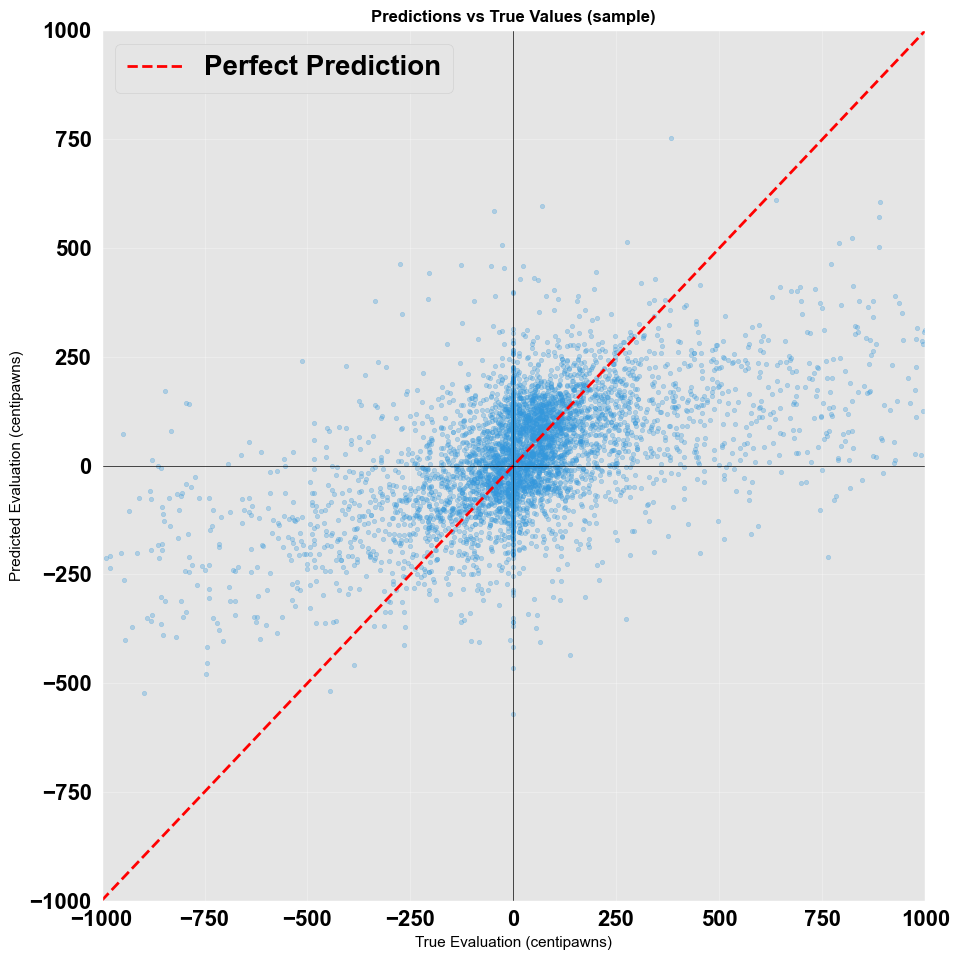

In [6]:
# Scatter plot
fig, ax = plt.subplots(figsize=(10, 10))

# Sample points for clearer visualization
sample_size = min(5000, len(mm.y_pred))
indices = np.random.choice(len(mm.y_pred), sample_size, replace=False)

y_true_sample = dm.y_test.iloc[indices]
y_pred_sample = mm.y_pred[indices]

ax.scatter(y_true_sample, y_pred_sample, alpha=0.3, s=10, color='#3498db')
ax.plot([-EVAL_THRESHOLD, EVAL_THRESHOLD], [-EVAL_THRESHOLD, EVAL_THRESHOLD], 
        'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlim(-EVAL_THRESHOLD, EVAL_THRESHOLD)
ax.set_ylim(-EVAL_THRESHOLD, EVAL_THRESHOLD)
ax.set_xlabel('True Evaluation (centipawns)', fontsize=11)
ax.set_ylabel('Predicted Evaluation (centipawns)', fontsize=11)
ax.set_title('Predictions vs True Values (sample)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## Tolerance-Accuracy Curve

This curve shows how accuracy improves as we allow more tolerance in predictions.

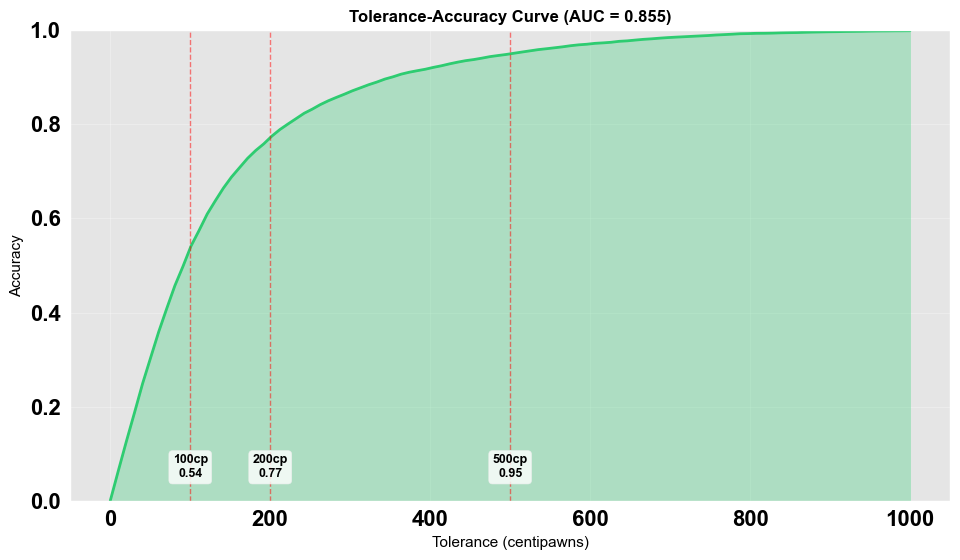

In [7]:
# Compute tolerance-accuracy curve
tolerances = np.linspace(0, 1000, 100)
accuracies = [metrics_m.centipawn_accuracy(int(t)) for t in tolerances]
auc = np.trapezoid(accuracies, tolerances) / 1000

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tolerances, accuracies, linewidth=2, color='#2ecc71')
ax.fill_between(tolerances, accuracies, alpha=0.3, color='#2ecc71')

ax.set_xlabel('Tolerance (centipawns)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(f'Tolerance-Accuracy Curve (AUC = {auc:.3f})', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# Mark specific tolerances
for tol in [100, 200, 500]:
    acc = metrics_m.centipawn_accuracy(tol)
    ax.axvline(x=tol, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(tol, 0.05, f'{tol}cp\n{acc:.2f}', ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Demonstrating the Importance of Ranking

Let's create a synthetic example to show why ranking matters more than exact values.

In [8]:
# Synthetic example: Compare two hypothetical predictors
np.random.seed(42)

# True evaluations for 10 positions
true_evals = np.array([-400, -200, -100, -50, 0, 50, 100, 200, 300, 500])

# Predictor 1: Close values but wrong ranking in some cases
pred1 = np.array([-380, -180, -120, -40, 10, 60, 90, 180, 320, 480])
pred1[[2, 3]] = pred1[[3, 2]]  # Swap two predictions (wrong ranking)

# Predictor 2: Scaled values (all multiplied by 0.7) but correct ranking
pred2 = true_evals * 0.7 + np.random.normal(0, 10, len(true_evals))

# Compute metrics for both
metrics_comparison = pd.DataFrame({
    'Metric': ['RMSE', 'Spearman Rank', 'Sign Accuracy'],
    'Predictor 1 (Wrong Ranking)': [
        np.sqrt(mean_squared_error(true_evals, pred1)),
        spearmanr(true_evals, pred1)[0],
        np.mean(np.sign(true_evals) == np.sign(pred1))
    ],
    'Predictor 2 (Correct Ranking)': [
        np.sqrt(mean_squared_error(true_evals, pred2)),
        spearmanr(true_evals, pred2)[0],
        np.mean(np.sign(true_evals) == np.sign(pred2))
    ]
})

print("\nSynthetic Example: Two Predictors\n")
print(metrics_comparison.round(4).to_string(index=False))


Synthetic Example: Two Predictors

       Metric  Predictor 1 (Wrong Ranking)  Predictor 2 (Correct Ranking)
         RMSE                      32.8634                        73.7646
Spearman Rank                       0.9879                         1.0000
Sign Accuracy                       0.9000                         0.9000


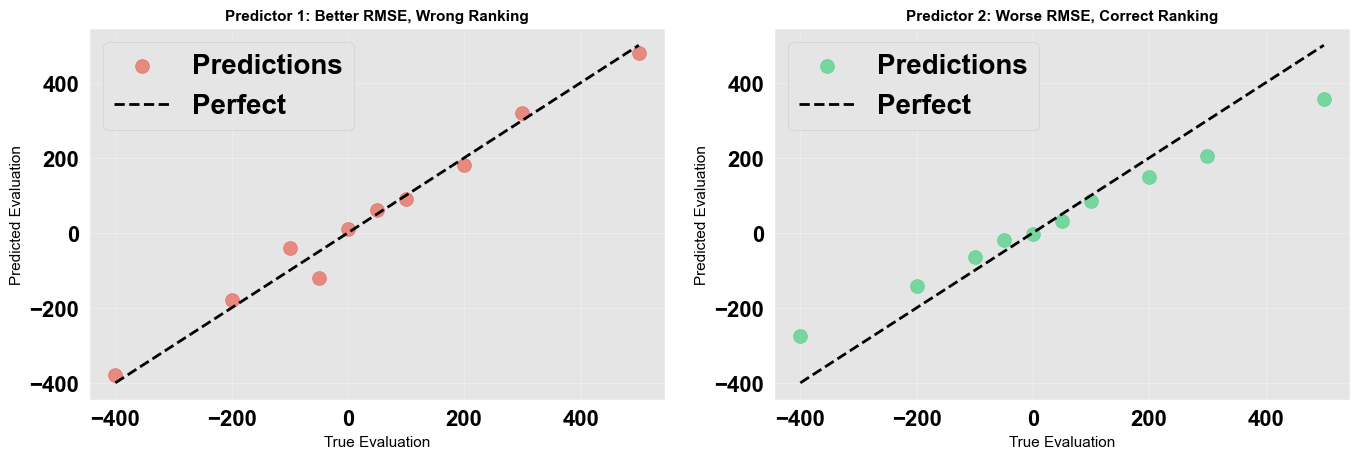

In [9]:
# Visualize the synthetic example
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictor 1
ax1 = axes[0]
ax1.scatter(true_evals, pred1, s=100, alpha=0.6, color='#e74c3c', label='Predictions')
ax1.plot(true_evals, true_evals, 'k--', linewidth=2, label='Perfect')
ax1.set_xlabel('True Evaluation', fontsize=11)
ax1.set_ylabel('Predicted Evaluation', fontsize=11)
ax1.set_title('Predictor 1: Better RMSE, Wrong Ranking', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Predictor 2
ax2 = axes[1]
ax2.scatter(true_evals, pred2, s=100, alpha=0.6, color='#2ecc71', label='Predictions')
ax2.plot(true_evals, true_evals, 'k--', linewidth=2, label='Perfect')
ax2.set_xlabel('True Evaluation', fontsize=11)
ax2.set_ylabel('Predicted Evaluation', fontsize=11)
ax2.set_title('Predictor 2: Worse RMSE, Correct Ranking', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Why Spearman Rank Correlation is the Best Metric

For chess evaluation, what matters is **correct ordering of positions**, not exact numeric values. Min-max search only needs to know which position is better after each possible move, so errors in magnitude (RMSE) are less relevant. Spearman rank correlation:

- Measures **relative ordering** directly  
- Is **robust to outliers** and monotonic transformations  
- Focuses on **decision-making**, not exact centipawns  

| Metric | Pros | Cons | Best Use |
|--------|------|------|----------|
| Spearman Rank | Ordering; robust; monotone-invariant | Ignores magnitude | Min-max search |
| RMSE | Easy to interpret | Sensitive to outliers; ignores order | Exact value prediction |
| R² | Shows variance explained | Can be negative; ignores order | Model comparison |
| Sign Accuracy | Simple | Too coarse | Basic winner prediction |
| Tolerance Accuracy | Practical threshold | Arbitrary tolerance | Approximate prediction |

For move selection, **ordering matters more than numeric accuracy**, making Spearman rank the ideal metric.
